#แยกบริเวณที่สนใจ (Threshold / HSV / Mask / Morphology)

**หัวข้อหลัก 3/4 ของ "ภาพรวม Image Processing"**

แยกวัตถุออกจากพื้นหลังด้วย **Threshold** , **HSV** , ทำความสะอาด Mask ด้วย
**Morphology**  และนับวัตถุด้วย **Contour**  — แต่ละหัวข้อโหลดภาพของตัวเองตอนเริ่ม
เพื่อให้เห็นว่าใช้ภาพไหนกับเรื่องอะไร


> เนื้อหาและภาพตัวอย่างอ้างอิงจากสไลด์ **COMPUTER VISIONS** โดย Asst.Prof.Dr. Amnach Khawne, King Mongkut's Institute of Technology Ladkrabang


## วิธีใช้ Notebook นี้

- รันทีละ Cell จากบนลงล่างด้วย **Shift + Enter**
- แต่ละหัวข้อแบ่งเป็น Cell ย่อยหลาย Cell ทำทีละขั้นตอน เพื่อให้เห็นผลลัพธ์ทันทีทีละ Cell
- ลองแก้ค่าตัวเลข (parameter) แล้วรันซ้ำ เพื่อดูว่าภาพเปลี่ยนไปอย่างไร
- **ต้องอัปโหลด `data.zip` ก่อน** (Cell ที่ 2) ทุกครั้งที่เปิด Notebook ใหม่ — Colab ลบไฟล์ทิ้งเมื่อ Runtime ถูกรีเซ็ต


## 0. เตรียมเครื่องมือ (Setup)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow  # แสดงภาพใน Colab แทน cv2.imshow()

print("OpenCV:", cv2.__version__)
print("NumPy :", np.__version__)


OpenCV: 5.0.0
NumPy : 2.1.3


In [2]:
def show_images(images, titles, cmap=None, figsize=(15, 5)):
    """แสดงภาพหลายภาพเรียงกันในแถวเดียว สำหรับเปรียบเทียบก่อน-หลัง"""
    n = len(images)
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, n, i + 1)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap or "gray", vmin=0, vmax=255)
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # BGR -> RGB สำหรับ matplotlib
        plt.title(title, fontsize=11)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


## 1. เตรียมชุดข้อมูล (Dataset) — อัปโหลด `data.zip`

อัปโหลดไฟล์ **`data.zip`** ที่ได้รับจากผู้สอน (ภาพชุดเดียวกับที่ใช้ในสไลด์ COMPUTER VISIONS)
เมื่อรัน Cell ด้านล่างจะมีปุ่มให้เลือกไฟล์จากเครื่อง — เลือก `data.zip` แล้วรอจนแตกไฟล์เสร็จ

In [3]:
import os
import zipfile

from google.colab import files

%cd /content
print("เลือกไฟล์ data.zip (ชุดภาพตัวอย่างจากสไลด์ COMPUTER VISIONS)")
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, "r") as zip_ref:
    zip_ref.extractall("/content/")

DATA_DIR = "/content/data"
print(f"แตกไฟล์ {zip_filename} เรียบร้อยแล้ว")
print("ไฟล์ภาพที่มีในโฟลเดอร์ data/:")
for fname in sorted(os.listdir(DATA_DIR)):
    print(" -", fname)


/content
เลือกไฟล์ data.zip (ชุดภาพตัวอย่างจากสไลด์ COMPUTER VISIONS)


Saving data_zip.zip to data_zip.zip
แตกไฟล์ data_zip.zip เรียบร้อยแล้ว
ไฟล์ภาพที่มีในโฟลเดอร์ data/:
 - README.txt
 - flower.jpg
 - graybars.jpg
 - label_tilted.jpg
 - mask_noisy.png
 - mask_ref.png
 - mask_staircase.png
 - oranges.jpg
 - pcb.jpg
 - shapes_black.jpg


## 2. Threshold พื้นฐาน — `cv2.threshold(img, T, maxval, cv2.THRESH_BINARY)`

ภาพที่ใช้: **graybars.jpg** — แถบสีเทา 3 ระดับ เหมาะกับการดูผลของค่า T ชัดเจน
กติกาของ `THRESH_BINARY`: พิกเซล > T → 255 (ขาว), พิกเซล ≤ T → 0 (ดำ)

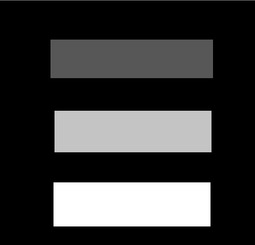

In [4]:
img_bars = cv2.imread(f"{DATA_DIR}/graybars.jpg")
gray_bars = cv2.cvtColor(img_bars, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray_bars)


Threshold T=50


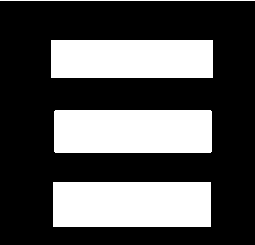

In [17]:
# T=50: ตั้งเกณฑ์ไว้ต่ำมาก (แค่สว่างเกิน 50 ก็กลายเป็นสีขาวแล้ว)
_, th50 = cv2.threshold(gray_bars, 50, 255, cv2.THRESH_BINARY)
print("Threshold T=50")
cv2_imshow(th50)

Threshold T=100


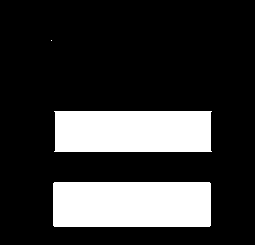

In [18]:
# T=100: ตั้งเกณฑ์ระดับกลางๆ (ต้องสว่างระดับนึงถึงจะกลายเป็นสีขาว)
_, th100 = cv2.threshold(gray_bars, 100, 255, cv2.THRESH_BINARY)
print("Threshold T=100")
cv2_imshow(th100)

Threshold T=210


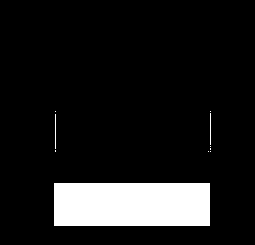

In [19]:
# T=210: ตั้งเกณฑ์ไว้สูงมาก (ต้องสว่างจัดๆ ถึงจะรอดเป็นสีขาว นอกนั้นดำหมด)
_, th210 = cv2.threshold(gray_bars, 210, 255, cv2.THRESH_BINARY)
print("Threshold T=210")
cv2_imshow(th210)

## 3. Threshold 5 แบบ — ต่างกันที่ "ผลลัพธ์" ไม่ใช่แค่ขาว-ดำ (สไลด์ 32)

อ้างอิง: [OpenCV — Image Thresholding](https://docs.opencv.org/4.13.0/d7/d4d/tutorial_py_thresholding.html)

1. ผลลัพธ์แบบ BINARY


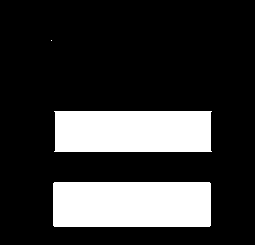

In [11]:
T = 100
# 1. BINARY: จุดที่สว่างกว่า T จะกลายเป็นสีขาว (255) ส่วนที่เหลือเป็นสีดำ (0)
_, binary = cv2.threshold(gray_bars, T, 255, cv2.THRESH_BINARY)
print("1. ผลลัพธ์แบบ BINARY")
cv2_imshow(binary)

2. ผลลัพธ์แบบ BINARY_INV


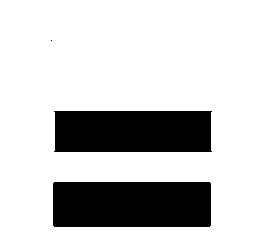

In [12]:
# 2. BINARY_INV: ตรงข้ามกับ BINARY (สว่างกว่า T เป็นสีดำ ส่วนที่เหลือเป็นสีขาว)
_, binary_inv = cv2.threshold(gray_bars, T, 255, cv2.THRESH_BINARY_INV)
print("2. ผลลัพธ์แบบ BINARY_INV")
cv2_imshow(binary_inv)

3. ผลลัพธ์แบบ TRUNC


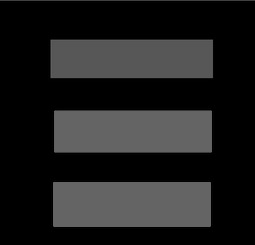

In [13]:
# 3. TRUNC: จุดที่สว่างกว่า T จะถูกตัดให้สว่างเท่ากับ T พอดี ส่วนจุดที่มืดกว่าจะคงเดิม
_, trunc = cv2.threshold(gray_bars, T, 255, cv2.THRESH_TRUNC)
print("3. ผลลัพธ์แบบ TRUNC")
cv2_imshow(trunc)

4. ผลลัพธ์แบบ TOZERO


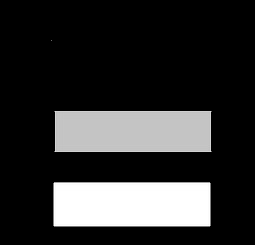

In [14]:
# 4. TOZERO: จุดที่มืดกว่า หรือเท่ากับ T จะกลายเป็นสีดำ (0) ส่วนจุดที่สว่างกว่าจะคงเดิม
_, tozero = cv2.threshold(gray_bars, T, 255, cv2.THRESH_TOZERO)
print("4. ผลลัพธ์แบบ TOZERO")
cv2_imshow(tozero)

5. ผลลัพธ์แบบ TOZERO_INV


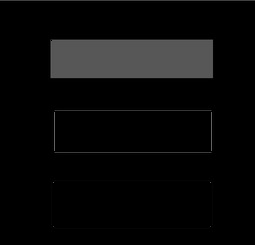

In [15]:
# 5. TOZERO_INV: ตรงข้ามกับ TOZERO (จุดที่สว่างกว่า T จะกลายเป็นสีดำ ส่วนจุดที่มืดกว่าจะคงเดิม)
_, tozero_inv = cv2.threshold(gray_bars, T, 255, cv2.THRESH_TOZERO_INV)
print("5. ผลลัพธ์แบบ TOZERO_INV")
cv2_imshow(tozero_inv)

## 4. Otsu's Threshold — ให้คอมพิวเตอร์เลือกค่า T อัตโนมัติ (สไลด์ 33)

`cv2.threshold(..., 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)` วิเคราะห์ Histogram แล้วเลือก T ให้เอง

ภาพต้นฉบับ (Original)


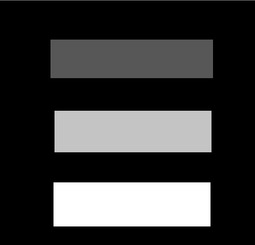

In [20]:
print("ภาพต้นฉบับ (Original)")
cv2_imshow(gray_bars)

สุ่มกำหนดค่า T เอง (Manual T=150)


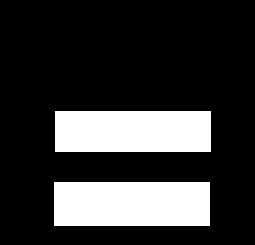

In [21]:
# ลองเดาค่า T ขึ้นมาเอง เช่น T = 150
_, manual_guess = cv2.threshold(gray_bars, 150, 255, cv2.THRESH_BINARY)
print("สุ่มกำหนดค่า T เอง (Manual T=150)")
cv2_imshow(manual_guess)

ค่า T ที่ Otsu คำนวณให้แบบอัตโนมัติคือ: 118.0
ผลลัพธ์จาก Otsu's Threshold


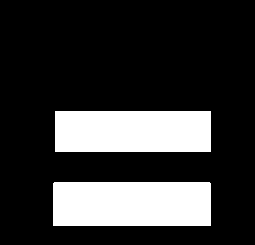

In [22]:
# เพิ่ม cv2.THRESH_OTSU เข้าไป เพื่อให้คอมพิวเตอร์วิเคราะห์หาค่า T ที่เหมาะสมที่สุดให้เอง
# สังเกตว่าเราจะใส่ค่าตำแหน่งที่ 2 เป็น 0 ไปก่อนได้เลย เพราะ Otsu จะหาค่าใหม่มาแทนที่ให้
otsu_T, otsu_result = cv2.threshold(gray_bars, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"ค่า T ที่ Otsu คำนวณให้แบบอัตโนมัติคือ: {otsu_T}")
print("ผลลัพธ์จาก Otsu's Threshold")
cv2_imshow(otsu_result)

## 5. Adaptive Threshold — ค่า T เปลี่ยนไปตามแต่ละบริเวณ

ภาพที่ใช้: **pcb.jpg** — แท่งสีเทาแบน ๆ ไม่มีรายละเอียดพอจะเห็นข้อดีของ Adaptive Threshold ต้องใช้ภาพที่มีพื้นผิว/ตัวอักษรจริง
เหมาะกับภาพที่แสงไม่สม่ำเสมอ — `blockSize` = ขนาดบริเวณที่ใช้คำนวณ T เฉพาะจุด (เลขคี่), `C` = ค่าคงที่ปรับ T

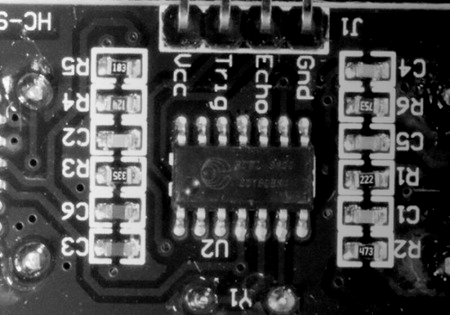

In [16]:
gray_pcb = cv2.cvtColor(cv2.imread(f"{DATA_DIR}/pcb.jpg"), cv2.COLOR_BGR2GRAY)

h, w = gray_pcb.shape
shade = np.tile(np.linspace(0, 100, w), (h, 1)).astype(np.uint8)
uneven = cv2.subtract(gray_pcb, shade)   # จำลองแสงไม่สม่ำเสมอ (มืดลงจากซ้ายไปขวา)
cv2_imshow(uneven)


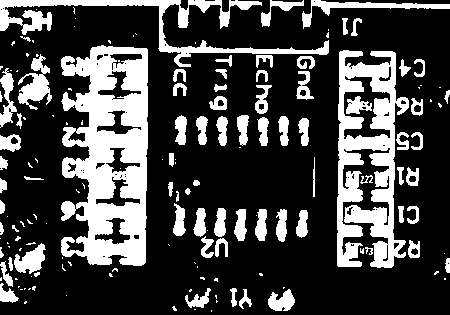

In [23]:
_, global_th = cv2.threshold(uneven, 100, 255, cv2.THRESH_BINARY)
cv2_imshow(global_th)   # ฝั่งขวาที่มืดกว่า รายละเอียดหายไปเยอะ


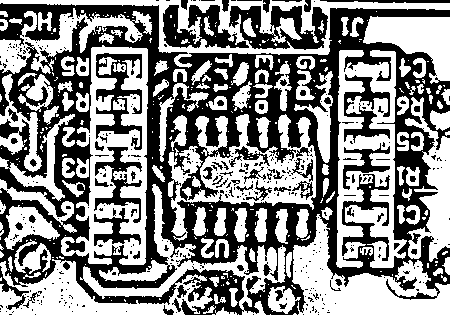

In [24]:
adaptive_th = cv2.adaptiveThreshold(uneven, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, blockSize=25, C=5)
cv2_imshow(adaptive_th)   # เห็นรายละเอียดครบทั้งฝั่งซ้ายและขวา แม้แสงไม่เท่ากัน


## 6. HSV Color Space

ภาพที่ใช้: **shapes_black.jpg** — รูปทรงหลายสีบนพื้นดำ
- **H (Hue)** เฉดสี, ช่วง 0–179 ใน OpenCV (มุมสีจริง 0–360° หาร 2 ให้พอดี uint8)
- **S (Saturation)** ความอิ่มตัวของสี, **V (Value)** ความสว่าง — ทั้งคู่ 0–255

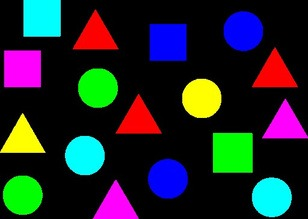

In [25]:
img_shapes = cv2.imread(f"{DATA_DIR}/shapes_black.jpg")
cv2_imshow(img_shapes)


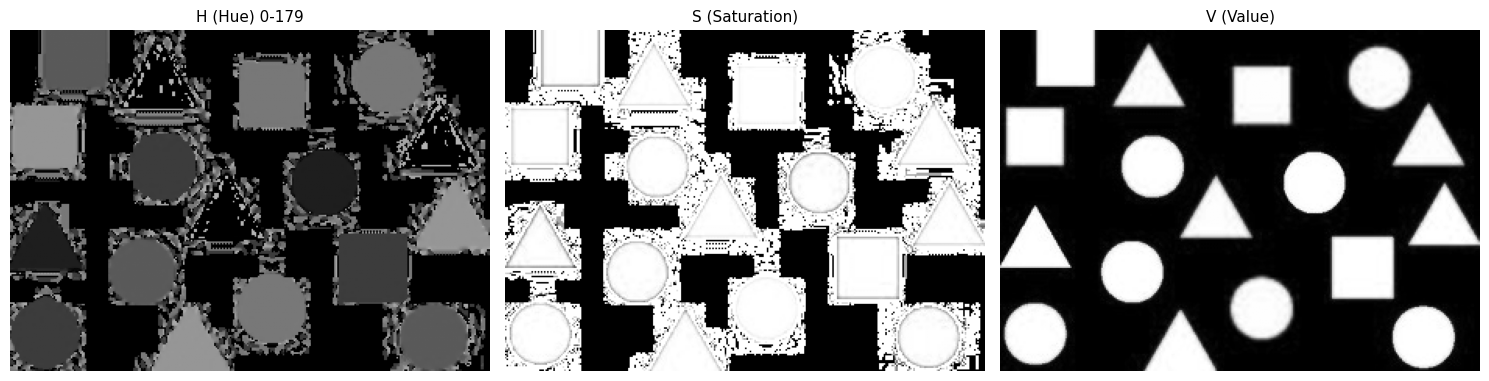

In [26]:
hsv = cv2.cvtColor(img_shapes, cv2.COLOR_BGR2HSV)
h_ch, s_ch, v_ch = cv2.split(hsv)

show_images([h_ch, s_ch, v_ch], ["H (Hue) 0-179", "S (Saturation)", "V (Value)"], cmap="gray")


## 7. เลือกวัตถุด้วยช่วงสี — `cv2.inRange()`

สีแดงอยู่บริเวณ "รอยต่อ" ของวง Hue (0 กับ 179 อยู่ติดกัน) จึงต้องใช้ 2 ช่วงแล้วรวมด้วย `cv2.bitwise_or()`

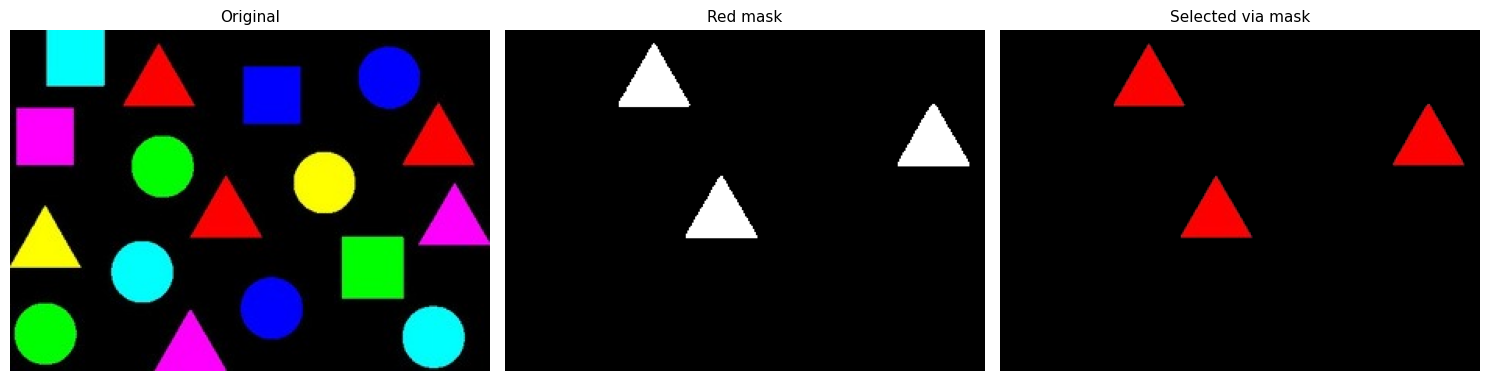

In [32]:
result_red = cv2.bitwise_and(img_shapes, img_shapes, mask=mask_red)
show_images([img_shapes, mask_red, result_red], ["Original", "Red mask", "Selected via mask"])


1. ภาพต้นฉบับ (Original)


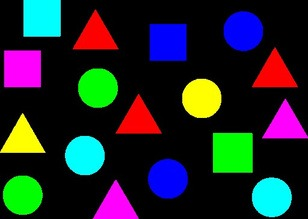

In [33]:
print("1. ภาพต้นฉบับ (Original)")
cv2_imshow(img_shapes)

2. Mask สีแดงช่วงแรก (Hue 0-10)


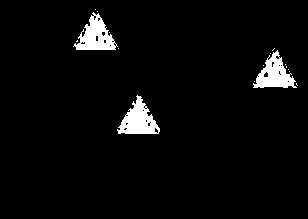

In [34]:
# สีแดงในระบบ HSV มีค่าอยู่ 2 ฝั่ง เราจึงต้องหาฝั่งแรกก่อน
# กำหนดช่วงสีแดงส่วนต้น (ค่าความสี หรือ Hue ตั้งแต่ 0 ถึง 10)
lower_red1 = (0, 120, 70)
upper_red1 = (10, 255, 255)

# สร้าง Mask: บริเวณที่เป็นสีแดงช่วงนี้จะกลายเป็นสีขาว (255) นอกนั้นเป็นสีดำ (0)
mask_red1 = cv2.inRange(hsv, lower_red1, upper_red1)
print("2. Mask สีแดงช่วงแรก (Hue 0-10)")
cv2_imshow(mask_red1)

3. Mask สีแดงช่วงที่สอง (Hue 170-179)


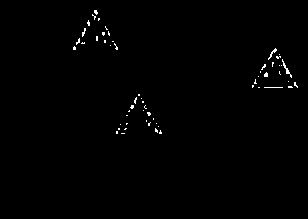

In [36]:
# กำหนดช่วงสีแดงส่วนปลาย (ค่าความสี หรือ Hue ตั้งแต่ 170 ถึง 179)
lower_red2 = (170, 120, 70)
upper_red2 = (179, 255, 255)

# สร้าง Mask ส่วนที่ 2
mask_red2 = cv2.inRange(hsv, lower_red2, upper_red2)
print("3. Mask สีแดงช่วงที่สอง (Hue 170-179)")
cv2_imshow(mask_red2)

4. Mask สีแดงรวมทั้งหมด (นำช่วง 1 และ 2 มารวมกัน)


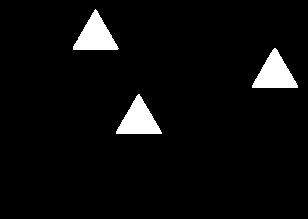

In [37]:
# นำ Mask สีขาวจากทั้ง 2 แผ่นมารวมกัน (ใช้คำสั่ง bitwise_or คือเอาพื้นที่สีขาวของทั้งคู่)
# เราก็จะได้พื้นที่ของ "สีแดงทั้งหมด" ในภาพ
mask_red = cv2.bitwise_or(mask_red1, mask_red2)
print("4. Mask สีแดงรวมทั้งหมด (นำช่วง 1 และ 2 มารวมกัน)")
cv2_imshow(mask_red)

5. ผลลัพธ์: ภาพที่ถูกดึงออกมาเฉพาะวัตถุสีแดง


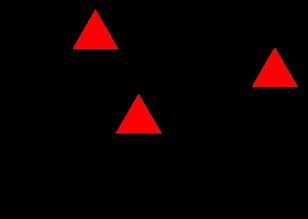

In [38]:
# นำหน้ากากรวม (mask_red) ไปทาบลงบนภาพต้นฉบับ
# bitwise_and จะเก็บเฉพาะภาพต้นฉบับในบริเวณที่หน้ากากเป็น "สีขาว" ไว้ ส่วนที่เป็นสีดำจะมืดสนิท
result_red = cv2.bitwise_and(img_shapes, img_shapes, mask=mask_red)

print("5. ผลลัพธ์: ภาพที่ถูกดึงออกมาเฉพาะวัตถุสีแดง")
cv2_imshow(result_red)

## 8. เปลี่ยนช่วง HSV → เลือกสีอื่น

1. Mask สีน้ำเงิน (Hue 100-130)


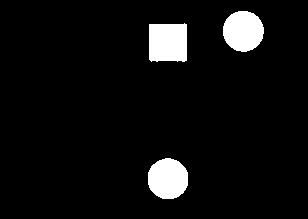

In [40]:
# สีน้ำเงินมีค่า Hue อยู่ในช่วง 100-130 (ทำรอบเดียวจบได้เลย)
lower_blue = (100, 120, 70)
upper_blue = (130, 255, 255)

# สร้าง Mask: บริเวณที่เป็นสีน้ำเงินจะกลายเป็นสีขาว ส่วนอื่นเป็นสีดำ
mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)
print("1. Mask สีน้ำเงิน (Hue 100-130)")
cv2_imshow(mask_blue)

2. ผลลัพธ์: วัตถุสีน้ำเงิน


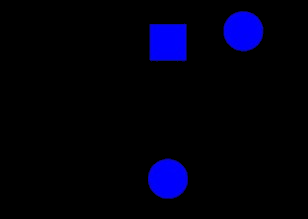

In [41]:
# นำหน้ากากไปทาบลงบนภาพต้นฉบับ เพื่อดึงมาเฉพาะส่วนที่ตรงกับสีขาว
result_blue = cv2.bitwise_and(img_shapes, img_shapes, mask=mask_blue)

print("2. ผลลัพธ์: วัตถุสีน้ำเงิน")
cv2_imshow(result_blue)

3. Mask สีเหลือง (Hue 20-35)


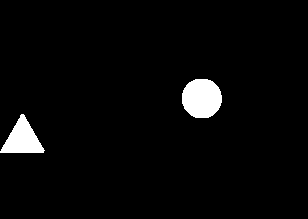

In [42]:
# สีเหลืองมีค่า Hue อยู่ในช่วง 20-35
lower_yellow = (20, 120, 70)
upper_yellow = (35, 255, 255)

# สร้าง Mask สีเหลือง
mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)
print("3. Mask สีเหลือง (Hue 20-35)")
cv2_imshow(mask_yellow)

4. ผลลัพธ์: วัตถุสีเหลือง


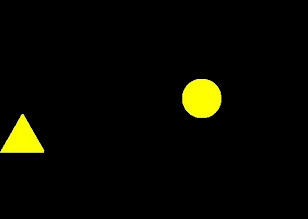

In [43]:
# นำหน้ากากไปทาบลงบนภาพต้นฉบับ
result_yellow = cv2.bitwise_and(img_shapes, img_shapes, mask=mask_yellow)

print("4. ผลลัพธ์: วัตถุสีเหลือง")
cv2_imshow(result_yellow)

## 9. Morphology — ทำความสะอาด Mask

ภาพที่ใช้: **mask_ref.png** (สะอาด) และ **mask_noisy.png** (มีจุดรบกวน 1 จุด, มีรูเล็ก 1 รู)
- **Erosion** หดพื้นที่ขาว → ลบจุดรบกวน
- **Dilation** ขยายพื้นที่ขาว → ปิดรูเล็ก
- **Opening** (Erode แล้ว Dilate) ลบจุดเล็กโดยไม่ทำให้วัตถุเล็กลง
- **Closing** (Dilate แล้ว Erode) ปิดรูเล็กโดยไม่ทำให้วัตถุใหญ่ขึ้น

1. ภาพต้นแบบที่สมบูรณ์ (Clean Reference)


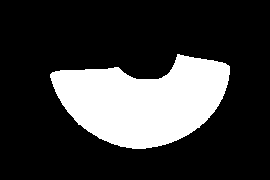

In [45]:
# 1. cv2.imread: ทำหน้าที่ไปดึงไฟล์ภาพจากโฟลเดอร์ที่กำหนด (DATA_DIR)
# 2. cv2.cvtColor(..., cv2.COLOR_BGR2GRAY): ถึงแม้ภาพหน้ากากจะดูเป็นสีขาวดำอยู่แล้ว
#    แต่คอมพิวเตอร์มักจะอ่านเข้ามาเป็นภาพสี (มี 3 ชั้นสี B-G-R) เราจึงต้องสั่งแปลงให้เป็นภาพขาวดำ (Grayscale) ชั้นเดียวจริงๆ
mask_ref = cv2.cvtColor(cv2.imread(f"{DATA_DIR}/mask_ref.png"), cv2.COLOR_BGR2GRAY)

print("1. ภาพต้นแบบที่สมบูรณ์ (Clean Reference)")
cv2_imshow(mask_ref)

2. ภาพที่มีจุดรบกวน (Noisy: Speck + Hole)


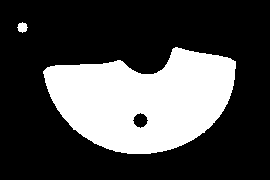

In [46]:
# โหลดภาพจำลองสถานการณ์จริง ที่เรามักจะเจอหลังจากการดึงสี (มีจุดขาวรบกวนด้านนอก และมีรูรั่วสีดำด้านใน)
mask_noisy = cv2.cvtColor(cv2.imread(f"{DATA_DIR}/mask_noisy.png"), cv2.COLOR_BGR2GRAY)

print("2. ภาพที่มีจุดรบกวน (Noisy: Speck + Hole)")
cv2_imshow(mask_noisy)

1. ภาพต้นฉบับ (Original)


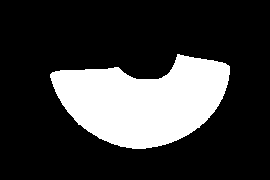

In [53]:
# สร้าง Kernel ซึ่งเปรียบเสมือน "หัวแปรง" หรือ "บล็อก" ที่เราจะเอาไปทาบลงบนภาพ
# ขนาด 11x11 พิกเซล (ข้อควรระวัง: ต้องตั้งขนาดให้ใหญ่กว่าจุดหรือรูรั่วที่เราต้องการจะลบ ไม่งั้นจะลบไม่หมด)
kernel = np.ones((11, 11), np.uint8)

print("1. ภาพต้นฉบับ (Original)")
cv2_imshow(mask_ref)

2. ผลลัพธ์ Erosion (สีขาวหดตัว / Shrink)


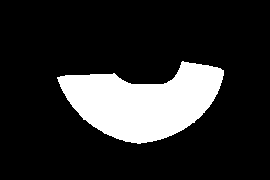

In [50]:
# Erosion จะทำการ "กัดเซาะ" ขอบของพื้นที่สีขาว ทำให้สีขาวหดเล็กลง
# ประโยชน์: ถ้ามี "จุดสีขาวเล็กๆ" (Noise) ลอยอยู่ข้างนอก มันจะถูกกัดเซาะจนหายไปเลย
eroded = cv2.erode(mask_ref, kernel, iterations=1)

print("2. ผลลัพธ์ Erosion (สีขาวหดตัว / Shrink)")
cv2_imshow(eroded)

3. ผลลัพธ์ Dilation (สีขาวขยายตัว / Grow)


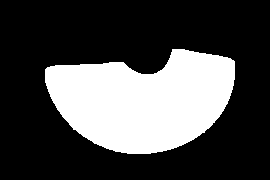

In [54]:
# Dilation จะทำงานตรงข้าม คือการ "พอกเพิ่ม" ขอบของพื้นที่สีขาว ทำให้สีขาวขยายใหญ่ขึ้น
# ประโยชน์: ถ้ามี "รูรั่วสีดำเล็กๆ" อยู่ข้างในพื้นที่สีขาว มันจะถูกสีขาวขยายมาทับจนอุดรูมิด
dilated = cv2.dilate(mask_ref, kernel, iterations=1)

print("3. ผลลัพธ์ Dilation (สีขาวขยายตัว / Grow)")
cv2_imshow(dilated)

1. ภาพเริ่มต้นที่มีปัญหา (Noisy Mask)


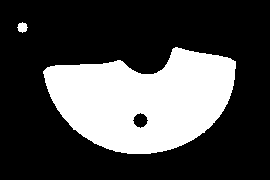

In [55]:
print("1. ภาพเริ่มต้นที่มีปัญหา (Noisy Mask)")
# ภาพนี้มีปัญหา 2 อย่างคือ: มี "จุดขาว" ลอยอยู่ข้างนอก และมี "รูดำ" รั่วอยู่ข้างใน
cv2_imshow(mask_noisy)

2. ผลลัพธ์หลังทำ Opening (ลบจุดรบกวนสีขาวด้านนอกเรียบร้อย)


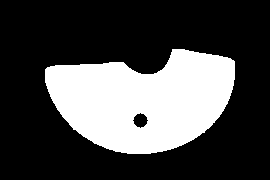

In [56]:
# Opening คือการทำ Erosion (กร่อน) แล้วตามด้วย Dilation (ขยาย) กลับทันที
# มันจะไป "กัดเซาะ" จุดขาวเล็กๆ ข้างนอกจนหายไป แล้วขยายภาพหลักกลับมาให้มีขนาดเท่าเดิม
opened = cv2.morphologyEx(mask_noisy, cv2.MORPH_OPEN, kernel)

print("2. ผลลัพธ์หลังทำ Opening (ลบจุดรบกวนสีขาวด้านนอกเรียบร้อย)")
cv2_imshow(opened)

3. ผลลัพธ์หลังทำ Closing (อุดรูรั่วสีดำด้านในเรียบร้อย ภาพกลับมาสมบูรณ์!)


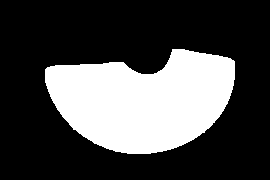

In [57]:
# Closing คือการทำ Dilation (ขยาย) แล้วตามด้วย Erosion (กร่อน) กลับทันที
# นำภาพจากขั้นตอนที่แล้ว (opened) มาทำต่อ สีขาวจะขยายไป "อุดรูรั่วสีดำ" ข้างในจนมิด แล้วขอบนอกจะถูกกร่อนให้กลับมาขนาดเท่าเดิม
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

print("3. ผลลัพธ์หลังทำ Closing (อุดรูรั่วสีดำด้านในเรียบร้อย ภาพกลับมาสมบูรณ์!)")
cv2_imshow(closed)

## 10. จาก Mask สู่ Contour — นับและวัดวัตถุ

ภาพที่ใช้: **oranges.jpg** — พาสต้า 4 ชิ้นบนพื้นหลังสีเขียว แยกสีพาสต้าออกจากพื้นหลังด้วย HSV ก่อน แล้วนับด้วย `cv2.findContours()`

1. ภาพต้นฉบับ (พาสต้าที่ต้องการค้นหา)


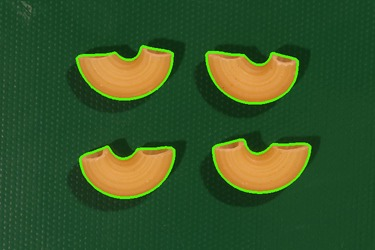

In [65]:
# โหลดไฟล์ภาพเข้ามา
img_pasta = cv2.imread(f"{DATA_DIR}/oranges.jpg")

print("1. ภาพต้นฉบับ (พาสต้าที่ต้องการค้นหา)")
cv2_imshow(img_pasta)

2. หน้ากากพาสต้า (ก่อนทำความสะอาด)


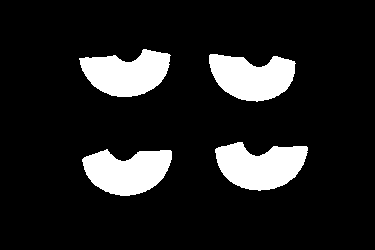

In [66]:
# แปลงภาพจาก BGR เป็น HSV เพื่อให้จับสีโทนส้ม-เหลืองของพาสต้าได้ง่ายขึ้น
hsv_pasta = cv2.cvtColor(img_pasta, cv2.COLOR_BGR2HSV)

# กำหนดช่วงของ "สีพาสต้า" (Hue ประมาณ 5 ถึง 25)
lower_pasta = (5, 100, 100)
upper_pasta = (25, 255, 255)

# สร้างหน้ากาก
mask_pasta_raw = cv2.inRange(hsv_pasta, lower_pasta, upper_pasta)

print("2. หน้ากากพาสต้า (ก่อนทำความสะอาด)")
# สังเกตว่าภาพนี้อาจจะมีจุดขาวๆ รบกวน หรือมีรูรั่วดำๆ ตามร่องหยักของพาสต้า
cv2_imshow(mask_pasta_raw)

3. หน้ากากพาสต้า (หลังทำ Closing และ Opening อุดรูและลบฝุ่นแล้ว)


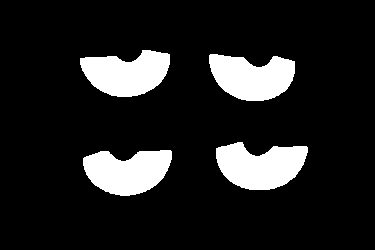

In [67]:
# สร้างหัวแปรง (Kernel) ขนาด 5x5 พิกเซล
kernel2 = np.ones((5, 5), np.uint8)

# ขั้นที่ 1: ทำ Closing (ขยายแล้วกร่อน) เพื่อ "อุดรูรั่วสีดำ" บนชิ้นพาสต้า
mask_pasta_clean = cv2.morphologyEx(mask_pasta_raw, cv2.MORPH_CLOSE, kernel2)

# ขั้นที่ 2: ทำ Opening (กร่อนแล้วขยาย) ต่อทันที เพื่อ "ลบเม็ดฝุ่นสีขาว" ที่อยู่รอบนอก
mask_pasta_clean = cv2.morphologyEx(mask_pasta_clean, cv2.MORPH_OPEN, kernel2)

print("3. หน้ากากพาสต้า (หลังทำ Closing และ Opening อุดรูและลบฝุ่นแล้ว)")
cv2_imshow(mask_pasta_clean)

4. ผลลัพธ์สุดท้าย: ดึงมาเฉพาะชิ้นพาสต้า!


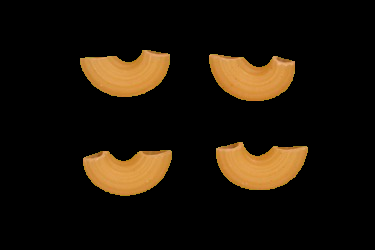

In [70]:
# นำหน้ากากที่สะอาดแล้ว ไปตัดชิ้นพาสต้าออกมาจากภาพต้นฉบับ
result_pasta = cv2.bitwise_and(img_pasta, img_pasta, mask=mask_pasta_clean)

print("4. ผลลัพธ์สุดท้าย: ดึงมาเฉพาะชิ้นพาสต้า!")
cv2_imshow(result_pasta)

In [71]:
# 1. ค้นหาเส้นขอบ (Contours) จากหน้ากากพาสต้าที่ทำความสะอาดแล้ว
# cv2.RETR_EXTERNAL: บอกว่าเราต้องการแค่เส้นขอบรอบนอกสุด ไม่เอาเส้นขอบของรูที่อาจจะหลงเหลืออยู่ข้างใน
contours, _ = cv2.findContours(mask_pasta_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 2. กรองเอาเฉพาะเส้นขอบที่มีขนาดพื้นที่ (Area) ใหญ่กว่า 300 พิกเซล
# เพื่อป้องกันการนับ "เศษฝุ่น" เล็กๆ ที่อาจจะยังรอดมาจากการทำความสะอาด
contours = [c for c in contours if cv2.contourArea(c) > 300]

print(f"ค้นพบชิ้นพาสต้าที่ผ่านเกณฑ์ทั้งหมด: {len(contours)} ชิ้น")

ค้นพบชิ้นพาสต้าที่ผ่านเกณฑ์ทั้งหมด: 4 ชิ้น


ผลลัพธ์การนับจำนวนและตีกรอบ:


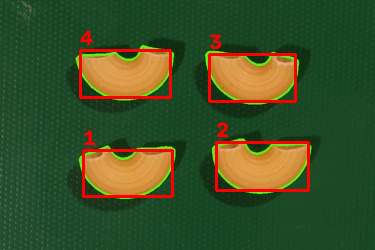

In [72]:
# สร้างสำเนาภาพต้นฉบับ เพื่อเอามาใช้วาดกรอบ (เราจะไม่วาดทับภาพจริง)
annotated = img_pasta.copy()

# วนลูปตามจำนวนเส้นขอบ (Contours) ที่หาได้ โดยเริ่มนับจาก 1
for i, c in enumerate(contours, start=1):
    # cv2.boundingRect: ตีกรอบสี่เหลี่ยมคลุมเส้นขอบนั้นๆ (ได้จุดมุมซ้ายบน x,y และความกว้าง w, ความสูง h)
    x, y, w, h = cv2.boundingRect(c)

    # วาดกรอบสี่เหลี่ยมสีแดง (0, 0, 255) ความหนาเส้น 2
    cv2.rectangle(annotated, (x, y), (x + w, y + h), (0, 0, 255), 2)

    # พิมพ์ตัวเลขกำกับไว้บนกรอบแต่ละอัน
    cv2.putText(annotated, str(i), (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

print("ผลลัพธ์การนับจำนวนและตีกรอบ:")
cv2_imshow(annotated)

## สรุปสิ่งที่เรียนในบทนี้

| แนวคิด | คำสั่งที่ใช้ | Parameter สำคัญ |
|---|---|---|
| Threshold พื้นฐาน | `cv2.threshold(img, T, maxval, type)` | T, type |
| Otsu (T อัตโนมัติ) | `cv2.THRESH_OTSU` | - |
| Adaptive Threshold | `cv2.adaptiveThreshold()` | blockSize, C |
| แปลงเป็น HSV | `cv2.cvtColor(BGR2HSV)` | - |
| เลือกช่วงสี | `cv2.inRange(lower, upper)` | lower/upper (H,S,V) |
| รวม/ตัด Mask | `cv2.bitwise_and/or/not()` | - |
| ทำความสะอาด Mask | `cv2.erode/dilate/morphologyEx()` | kernel size |
| นับ/วัดวัตถุ | `cv2.findContours()`, `cv2.boundingRect()` | - |

**บทถัดไป:** Module 4.4 — จัดการพิกัดและมุมมอง (ROI / Crop / Resize / Perspective)


## แบบฝึกหัดท้ายบท (ลองทำเอง)

1. เปลี่ยนค่า `blockSize` และ `C` ของ Adaptive Threshold ในหัวข้อ 5
2. ปรับช่วง H ในหัวข้อ 8 ให้เลือกสีเขียวหรือสีม่วงแทน
3. เปลี่ยนขนาด `kernel` ในหัวข้อ 9 จาก (11,11) เป็น (5,5) แล้วสังเกตว่าลบจุด/ปิดรูไม่หมด เพราะ kernel เล็กกว่าจุด/รูนั้น
4. เปลี่ยนช่วงสีในหัวข้อ 10 แล้วดูว่ายังนับพาสต้าได้ครบ 4 ชิ้นหรือไม่
